<a href="https://colab.research.google.com/github/zeynepbykn/SMS_Spam_Tespiti_Proje/blob/main/SMS_spam_veriBilimi_proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Veriyi Okuma ve İstatistikleri **Çıkarma**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
import io

# 1. ADIM: Veriyi doğrudan UCI sitesinden indiriyoruz (Zeynep & Kübra Ortak)
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
response = requests.get(url)

# 2. ADIM: İndirilen zip içeriğini açıyoruz
with zipfile.ZipFile(io.BytesIO(response.content), 'r') as zip_ref:
    zip_ref.extractall('sms_data') # 'sms_data' isimli bir klasöre çıkartır


df = pd.read_csv('sms_data/SMSSpamCollection', sep='\t', names=['label', 'message'])

print("Veri Seti Boyutu:", df.shape) # (5574, 2):5574 mesaj ve 2 sütun
## df.head(): Tablonun en üstündeki ilk 5 satırı ekrana getirir,kontrol etmemizi sağlar.
print("\nİlk 5 Satır:\n", df.head())

# Sınıf Dağılımı
# label sütunundaki değerleri sayar:kaç tane ham,spam mesaj oldugu yazıyor.
print("\nSınıf Sayıları:")
print(df['label'].value_counts())

Veri Seti Boyutu: (5572, 2)

İlk 5 Satır:
   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Sınıf Sayıları:
label
ham     4825
spam     747
Name: count, dtype: int64


Görselleştirme (Grafik) **Kodları**

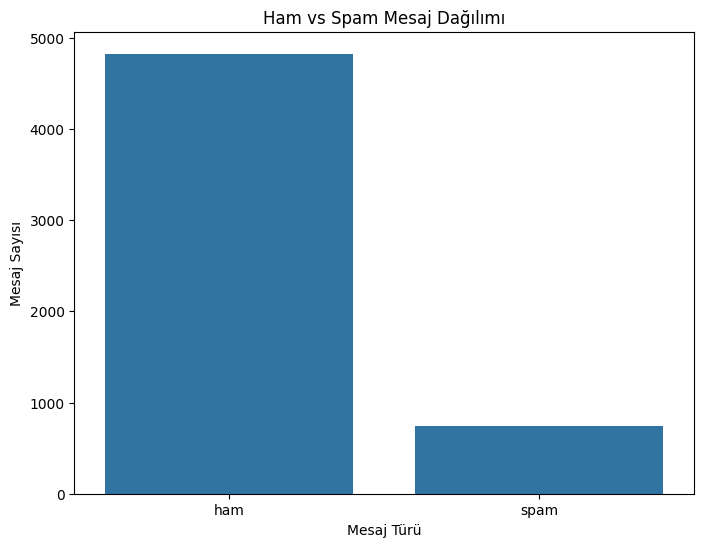

In [ ]:
# Grafiğin boyutu: (8 birim genişlik, 6 birim yükseklik).
plt.figure(figsize=(8,6))

# sns.countplot: Kategorik veriler için (ham/spam) sütun grafiği çizer.
# x='label': Alt eksende etiketler (ham ve spam) yer alacak.
sns.countplot(x='label', data=df)

# Grafiğe başlık ve eksen isimleri ekliyoruz.
plt.title('Ham vs Spam Mesaj Dağılımı') # Grafiğin ana başlığı.
plt.xlabel('Mesaj Türü') # Yatay eksen ismi.
plt.ylabel('Mesaj Sayısı') # Dikey eksen ismi.

# plt.show ile grafiği çizer
plt.show()

# Veri Temizliği(NLP Preprocessing)

In [ ]:
import string
import nltk
from nltk.corpus import stopwords

# Gerekli paketleri indiriyoruz
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def temizle(metin):
    metin = metin.lower() # Hepsini kucuk harfe çevirir.
    metin = ''.join([char for char in metin if char not in string.punctuation]) # Noktalama işaretlerini kaldırır.
    metin = ''.join([char for char in metin if not char.isdigit()]) # Sayıları kaldırır.
    metin = ' '.join([kelime for kelime in metin.split() if kelime not in stop_words]) # Stopwords(the,is,and..)
    return metin

# Temizlemeden önce orijinal uzunluğu ölçelim
df['mesaj_uzunluk'] = df['message'].apply(len)
#spam mesajlar genelde daha uzundur.

# Temizleme işlemini uygulayalım
df['temiz_mesaj'] = df['message'].apply(temizle)

print("Temizleme işlemi tamamlandı!")
print("\n--- Makale İçin Ön Analiz ---")
# Spam ve Ham mesajların uzunluk farkını görelim
print(df.groupby('label')['mesaj_uzunluk'].mean())

Temizleme işlemi tamamlandı!

--- Makale İçin Ön Analiz ---
label
ham      71.482487
spam    138.670683
Name: mesaj_uzunluk, dtype: float64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# TF-IDF (Kelime Ağırlıgı Hesaplama)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF nesnesini oluşturuyoruz
# max_features=3000: En önemli 3000 kelimeyi alıyoruz(tum kelimeleri alırsak gurultu katabilir,modelin kafası karışabilir)
tfidf = TfidfVectorizer(max_features=3000)

# Temizlenmiş mesajlarımızı sayılara dönüştürüyoruz(Çunku model sayılardan anlıyor.)
X = tfidf.fit_transform(df['temiz_mesaj']).toarray()

# Hedef değişkenimizi (spam mi ham mi) sayısallaştırıyoruz
# ham = 0, spam = 1
y = df['label'].map({'ham': 0, 'spam': 1}).values

print("Vektörleştirme Tamamlandı!")
print("X (Girdi) Boyutu:", X.shape) # (5572, 3000) gibi bir sonuç gelmeli

Vektörleştirme Tamamlandı!
X (Girdi) Boyutu: (5572, 3000)


# Eğitim ve Test Olarak Bölme

In [ ]:
from sklearn.model_selection import train_test_split

# Verinin %20'sini test (sınav), %80'ini eğitim (ders çalışma) için ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Eğitim seti (X_train) boyutu:", X_train.shape)
print("Test seti (X_test) boyutu:", X_test.shape)

Eğitim seti (X_train) boyutu: (4457, 3000)
Test seti (X_test) boyutu: (1115, 3000)


RANDOM FOREST MODELİ

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Modeli oluştur
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Modeli eğit
rf_model.fit(X_train, y_train)

# 3. Tahmin yap
y_pred_rf = rf_model.predict(X_test)

# 4. Sonuçları yazdır
print(f"Doğruluk: %{accuracy_score(y_test, y_pred_rf)*100:.2f}")

Doğruluk: %98.12


NAVİE BAYES **MODELİ**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# MultinomialNB():
# Naive Bayes'in "çok terimli" versiyonudur. TF-IDF gibi kelime sayımları ve ağırlıklarıyla çalışmak üzere tasarlanmıştır.
#  Naive Bayes modelini (Multinomial versiyonu) oluşturuyoruz
nb_model = MultinomialNB()

# Modeli eğitim verilerimizle eğitiyoruz(%80)
# X_train: (Kelime ağırlıkları), y_train: Ham/Spam (0/1)
nb_model.fit(X_train, y_train)

# Modeli teste sokuyoruz(%20 lik kısım)
y_pred = nb_model.predict(X_test)

# Başarıyı ölçüyoruz
print("--- Naive Bayes Performans Sonuçları ---")
# Modelin tahminleri (y_pred) ile gerçek cevapları (y_test) karşılaştırır.
print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred)*100:.2f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

--- Naive Bayes Performans Sonuçları ---
Doğruluk (Accuracy) Skoru: %98.03

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



**BAYES-Metriklerin Sütun Grafiği**

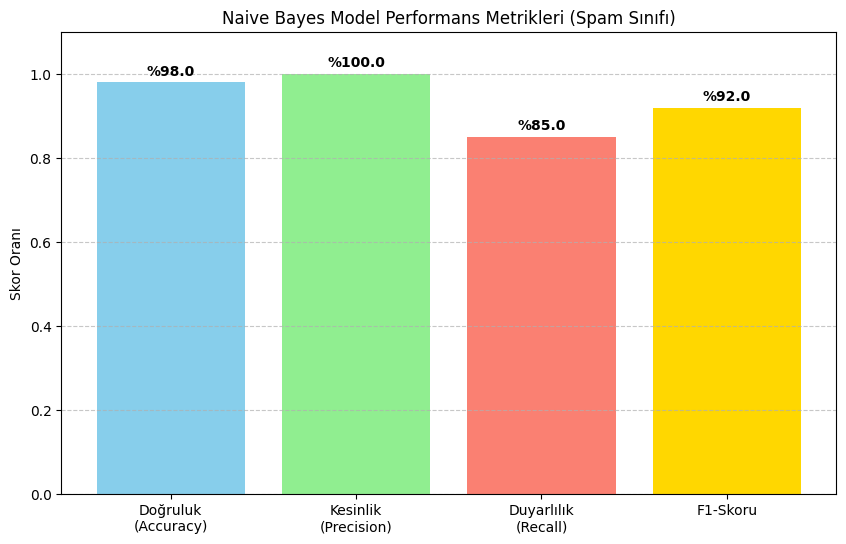

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#  Metrik değerlerini bir listeye alıyoruz
metrik_isimleri = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
# Spam (1) sınıfına ait değerleri baz alıyoruz çünkü başarımızı o belirliyor
metrik_degerleri = [0.98, 1.00, 0.85, 0.92]

#  Grafik oluşturma
plt.figure(figsize=(10, 6))
renkler = ['skyblue', 'lightgreen', 'salmon', 'gold']
barlar = plt.bar(metrik_isimleri, metrik_degerleri, color=renkler)

#  Grafik üzerine değerleri (yüzdeleri) yazdıralım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

#  Grafik süslemeleri
plt.ylim(0, 1.1) # Üst sınırı biraz boş bırakalım ki sayılar görünsün
plt.ylabel('Skor Oranı')
plt.title('Naive Bayes Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# BAYES-Karmaşıklık Matrisi

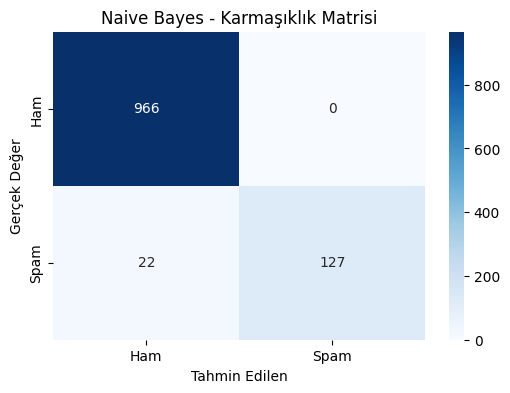

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Naive Bayes - Karmaşıklık Matrisi')
plt.show()

Random Forest Karmaşıklık Matrisi (Heatmap)

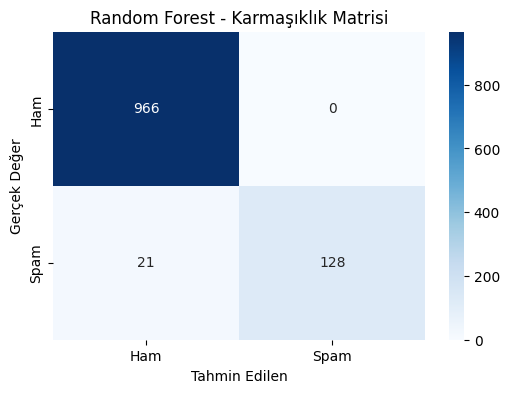

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# rf_model ve y_pred_rf isimlerini yukarıdaki kodlarına göre kontrol et
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Random Forest - Karmaşıklık Matrisi')
plt.show()

Random forest Performans Metrikleri Çubuk Grafiği

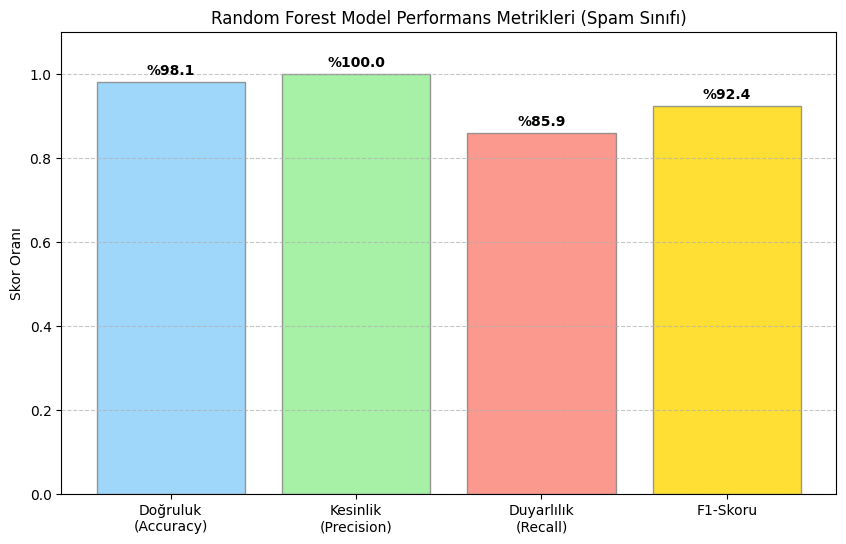

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Metrikleri hesaplayalım (Spam sınıfı için)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')

metrikler = ['Doğruluk\n(Accuracy)', 'Kesinlik\n(Precision)', 'Duyarlılık\n(Recall)', 'F1-Skoru']
skorlar = [acc_rf, prec_rf, rec_rf, f1_rf]
renkler = ['lightskyblue', 'lightgreen', 'salmon', 'gold']

# Grafik çizimi
plt.figure(figsize=(10, 6))
barlar = plt.bar(metrikler, skorlar, color=renkler, edgecolor='gray', alpha=0.8)

# Çubukların üzerine yüzde değerlerini yazalım
for bar in barlar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'%{yval*100:.1f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı')
plt.title('Random Forest Model Performans Metrikleri (Spam Sınıfı)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()